In [2]:
!pip install fastai
import pandas as pd
from fastai.vision.all import *

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 83.2 MB/s eta 0:00:00:00:01:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.

In [3]:
df = pd.read_csv('/kaggle/input/datasets/gpiosenka/sports-classification/sports.csv')
df.head()

,class id,filepaths,labels,data set
0,0,train/air hockey/001.jpg,air hockey,train
1,0,train/air hockey/002.jpg,air hockey,train
2,0,train/air hockey/003.jpg,air hockey,train
3,0,train/air hockey/004.jpg,air hockey,train
4,0,train/air hockey/005.jpg,air hockey,train


path for accessing the datas

In [4]:
path = Path('/kaggle/input/datasets/gpiosenka/sports-classification')


In [5]:
df.columns = df.columns.str.replace(' ', '_').str.lower()
df.head()

,class_id,filepaths,labels,data_set
0,0,train/air hockey/001.jpg,air hockey,train
1,0,train/air hockey/002.jpg,air hockey,train
2,0,train/air hockey/003.jpg,air hockey,train
3,0,train/air hockey/004.jpg,air hockey,train
4,0,train/air hockey/005.jpg,air hockey,train


In [6]:
df_clean = df[df['data_set']!='test'].reset_index(drop=True)
print('The shape of training dataset is:', df_clean[df_clean['data_set']=='train'].shape)
print('The shape of valid dataset is:', df_clean[df_clean['data_set']=='valid'].shape)


The shape of training dataset is: (13493, 4)
The shape of valid dataset is: (500, 4)


Checking whether the column splitter is working properly or not based on the column data_set 

In [7]:
splitter = ColSplitter('data_set')(df_clean)
print("Train size:", len(splitter[0]))
print("Valid size:", len(splitter[1]))

Train size: 0
Valid size: 13993


creating a new column called is_valid, based on the column data_set for splitting the data

In [8]:
df_clean['is_valid'] = df_clean['data_set'] == 'valid'
df_clean.head()

,class_id,filepaths,labels,data_set,is_valid
0,0,train/air hockey/001.jpg,air hockey,train,False
1,0,train/air hockey/002.jpg,air hockey,train,False
2,0,train/air hockey/003.jpg,air hockey,train,False
3,0,train/air hockey/004.jpg,air hockey,train,False
4,0,train/air hockey/005.jpg,air hockey,train,False


we are only taking the rows where the filepath has the actual image data rather than other datas, with the help of image_extensions api of fastai

In [9]:
df_clean = df_clean[df_clean['filepaths'].str.lower().str.endswith(tuple(image_extensions))].reset_index(drop=True)  

In [10]:
datablock = DataBlock(blocks=(ImageBlock, CategoryBlock),
                   splitter=ColSplitter('is_valid'),   #based on the column 'data_set' in the dataframe, we are splitting the datas
                   get_x=ColReader('filepaths',pref=path),   #the source of the data is the path to the image, and we are using the path as the prefix to each filepaths
                   get_y=ColReader('labels'),    #labels to identify the category of the image
                   item_tfms = [Resize(192, method = 'squish')],
                   )


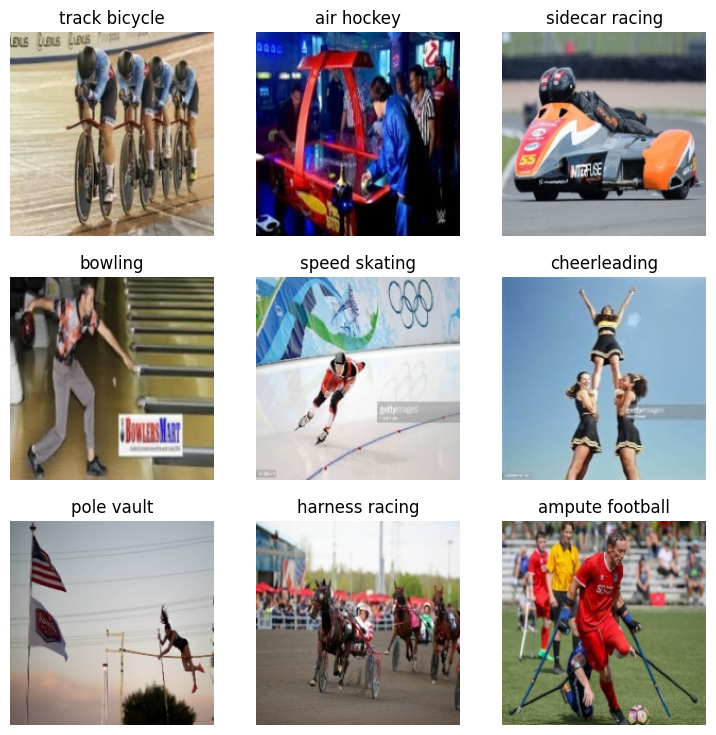

In [11]:
dls = datablock.dataloaders(df_clean)  #loading the data in our designed datablock
dls.show_batch()

Fine-tuning the model

In [12]:
learn = vision_learner(dls,resnet18, metrics = error_rate)
learn.fine_tune(3)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 157MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,2.149604,0.776837,0.216000,00:36


epoch,train_loss,valid_loss,error_rate,time
0,0.887378,0.407889,0.130000,00:31
1,0.414155,0.252876,0.068000,00:33
2,0.155182,0.222920,0.066000,00:35


In [13]:
df[df['data_set'] == 'test']

,class_id,filepaths,labels,data_set
13493,0,test/air hockey/1.jpg,air hockey,test
13494,0,test/air hockey/2.jpg,air hockey,test
13495,0,test/air hockey/3.jpg,air hockey,test
13496,0,test/air hockey/4.jpg,air hockey,test
13497,0,test/air hockey/5.jpg,air hockey,test
...,...,...,...,...
13988,99,test/wingsuit flying/1.jpg,wingsuit flying,test
13989,99,test/wingsuit flying/2.jpg,wingsuit flying,test
13990,99,test/wingsuit flying/3.jpg,wingsuit flying,test
13991,99,test/wingsuit flying/4.jpg,wingsuit flying,test


editing the filepaths inorder to match with the path of datas

In [14]:
df['filepaths'] = str(path) + '/' + df['filepaths']
df.head()

,class_id,filepaths,labels,data_set
0,0,/kaggle/input/datasets/gpiosenka/sports-classification/train/air hockey/001.jpg,air hockey,train
1,0,/kaggle/input/datasets/gpiosenka/sports-classification/train/air hockey/002.jpg,air hockey,train
2,0,/kaggle/input/datasets/gpiosenka/sports-classification/train/air hockey/003.jpg,air hockey,train
3,0,/kaggle/input/datasets/gpiosenka/sports-classification/train/air hockey/004.jpg,air hockey,train
4,0,/kaggle/input/datasets/gpiosenka/sports-classification/train/air hockey/005.jpg,air hockey,train


prediction done by our trained model on test dataset

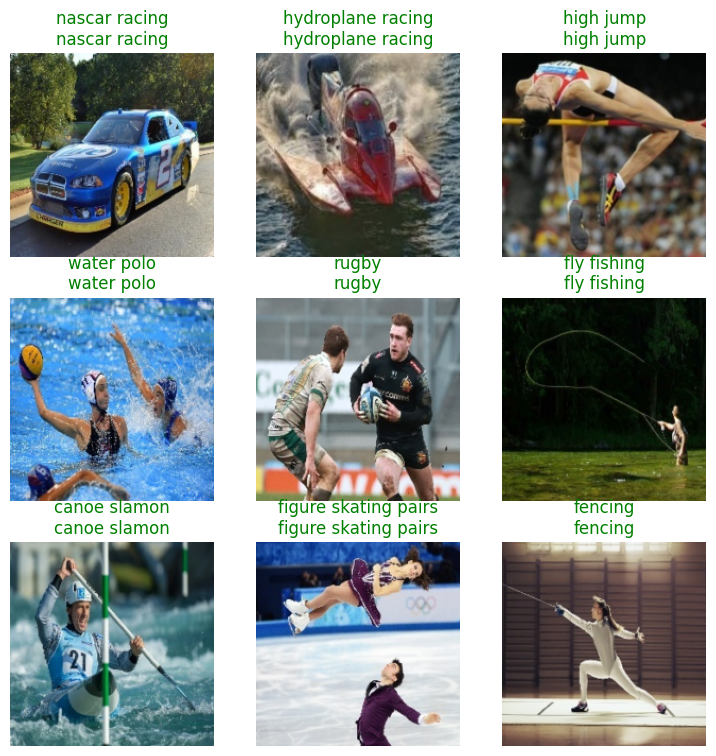

In [15]:
learn.predict(df[df['data_set']=='test']['filepaths'].iloc[10])
learn.show_results()

As we can see from the above images and labels, our model is correctly classifying the image.